# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

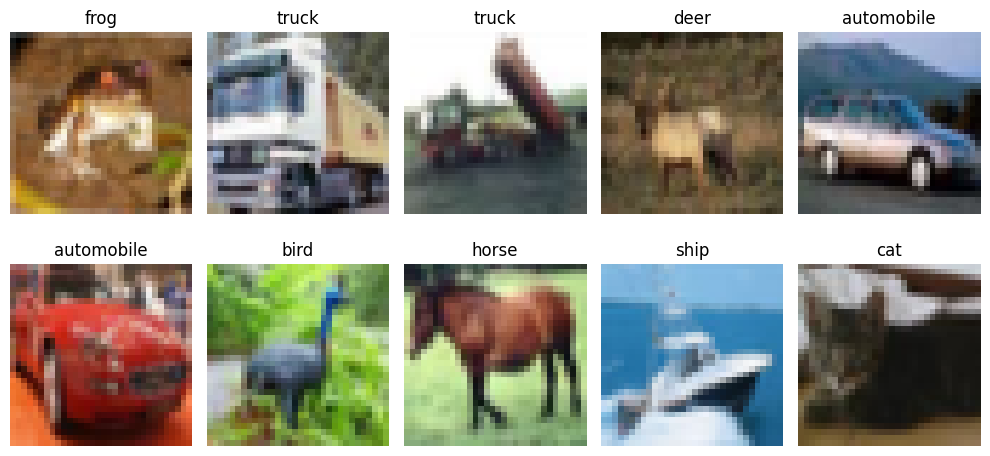

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.2685 - loss: 1.9929 - val_accuracy: 0.3436 - val_loss: 1.8284
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.3187 - loss: 1.8626 - val_accuracy: 0.3696 - val_loss: 1.7702
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3394 - loss: 1.8173 - val_accuracy: 0.3596 - val_loss: 1.7507
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3514 - loss: 1.7864 - val_accuracy: 0.3654 - val_loss: 1.7302
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3554 - loss: 1.7637 - val_accuracy: 0.3918 - val_loss: 1.7060
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3658 - loss: 1.7384 - val_accuracy: 0.4062 - val_loss: 1.6841
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.3733 - loss: 1.7214 - val_accuracy: 0.4136 - val_loss: 1.6856
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3806 - loss: 1.6998 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4294 - loss: 1.6411
ANN Test Accuracy: 0.4293999969959259


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - accuracy: 0.4749 - loss: 1.4828 - val_accuracy: 0.5812 - val_loss: 1.1871
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.6097 - loss: 1.1172 - val_accuracy: 0.6022 - val_loss: 1.1098
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.6668 - loss: 0.9580 - val_accuracy: 0.6492 - val_loss: 1.0159
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.7082 - loss: 0.8406 - val_accuracy: 0.6896 - val_loss: 0.9103
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.7412 - loss: 0.7428 - val_accuracy: 0.6836 - val_loss: 0.9422
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.7693 - loss: 0.6562 - val_accuracy: 0.7036 - val_loss: 0.9110
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.7889 - loss: 0.5937 - val_accuracy: 0.6934 - val_loss: 0.9519
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.8129 - loss: 0.5278 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6902 - loss: 1.1083
CNN Test Accuracy: 0.6901999711990356


## 📈 Compare Learning Curves

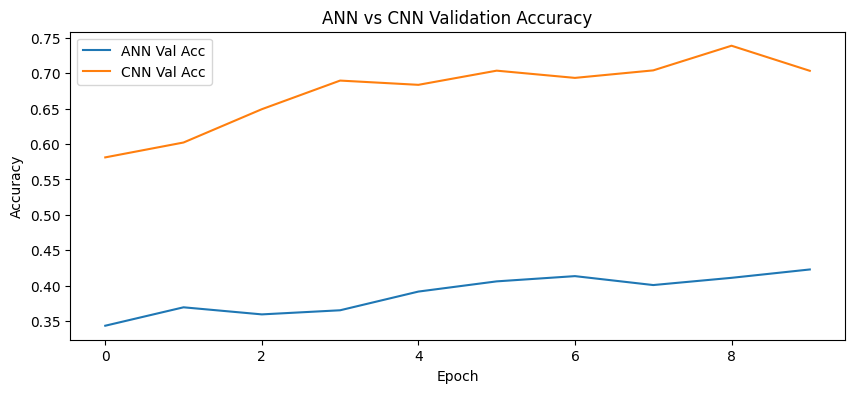

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4294
1,CNN,0.6902


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## Student Task 1: Increased ANN Layers
Adding more Dense layers to the ANN to observe if depth improves performance.

In [12]:
# Task 1: Increased ANN layers
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

ann_history_v2 = ann_model_v2.fit(x_train_flat, y_train,
                                   epochs=10,
                                   validation_split=0.1,
                                   batch_size=64)

ann_v2_loss, ann_v2_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_v2_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.2032 - loss: 2.1004 - val_accuracy: 0.2752 - val_loss: 1.9421
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.2655 - loss: 1.9507 - val_accuracy: 0.3222 - val_loss: 1.8736
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.2888 - loss: 1.9054 - val_accuracy: 0.3250 - val_loss: 1.8646
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3020 - loss: 1.8813 - val_accuracy: 0.3308 - val_loss: 1.8470
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3113 - loss: 1.8689 - val_accuracy: 0.3560 - val_loss: 1.8181
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.3144 - loss: 1.8500 - val_accuracy: 0.3470 - val_loss: 1.8078
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.3218 - loss: 1.8391 - val_accuracy: 0.3534 - val_loss: 1.7970
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.3245 - loss: 1.8287 - 

## Observation - Task 1
Adding more Dense layers to the ANN reduced accuracy from 42.94% to 37.61%.
This confirms that deeper ANNs do not necessarily perform better on image data.
The ANN treats images as flat vectors, losing all spatial information.
More layers with dropout caused the model to underfit rather than improve.

## Student Task 2: Modified CNN Filter Sizes
Scaling up CNN filters from 32→64→128 to 64→128→256 to extract richer features.

In [13]:
# Task 2: Modified CNN with larger filters
cnn_model_v2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

cnn_history_v2 = cnn_model_v2.fit(x_train_norm, y_train,
                                   epochs=10,
                                   validation_split=0.1,
                                   batch_size=64)

cnn_v2_loss, cnn_v2_acc = cnn_model_v2.evaluate(x_test_norm, y_test)
print("Larger Filter CNN Test Accuracy:", cnn_v2_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 223ms/step - accuracy: 0.4731 - loss: 1.6124 - val_accuracy: 0.4682 - val_loss: 1.5032
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 160s 227ms/step - accuracy: 0.6281 - loss: 1.0749 - val_accuracy: 0.5136 - val_loss: 1.5384
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 232ms/step - accuracy: 0.6915 - loss: 0.8753 - val_accuracy: 0.5768 - val_loss: 1.2376
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 226ms/step - accuracy: 0.7416 - loss: 0.7467 - val_accuracy: 0.6908 - val_loss: 0.8985
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 205s 231ms/step - accuracy: 0.7774 - loss: 0.6360 - val_accuracy: 0.7112 - val_loss: 0.8962
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 158s 224ms/step - accuracy: 0.8059 - loss: 0.5546 - val_accuracy: 0.7452 - val_loss: 0.7882
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 231ms/step - accuracy: 0.8292 - loss: 0.4757 - val_accuracy: 0.6576 - val_loss: 1.2217
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 151s 214ms/step - accuracy: 0.8537 -

## Observation - Task 2
Scaling CNN filters to 64→128→256 gave 68.25% accuracy, slightly below the original 69.02%.
Training accuracy reached 89% but test accuracy dropped, indicating overfitting.
Larger filters increased training time significantly (18+ minutes vs original).
More filters extract richer features but also overfit more on a small dataset like CIFAR-10.

## Student Task 3 & 4: Increase Epochs to 20 + EarlyStopping
Training the original CNN for 20 epochs with EarlyStopping to prevent overfitting.

In [14]:
# Task 3 & 4: 20 epochs with EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy',
                           patience=3,
                           restore_best_weights=True)

cnn_model_v3 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v3.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

cnn_history_v3 = cnn_model_v3.fit(x_train_norm, y_train,
                                   epochs=20,
                                   validation_split=0.1,
                                   batch_size=64,
                                   callbacks=[early_stop])

cnn_v3_loss, cnn_v3_acc = cnn_model_v3.evaluate(x_test_norm, y_test)
print("20 Epoch CNN with EarlyStopping Test Accuracy:", cnn_v3_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 80ms/step - accuracy: 0.4719 - loss: 1.5620 - val_accuracy: 0.4772 - val_loss: 1.5963
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6159 - loss: 1.0927 - val_accuracy: 0.5928 - val_loss: 1.1625
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 80ms/step - accuracy: 0.6778 - loss: 0.9212 - val_accuracy: 0.6682 - val_loss: 0.9315
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.7179 - loss: 0.7997 - val_accuracy: 0.6084 - val_loss: 1.1677
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 78ms/step - accuracy: 0.7484 - loss: 0.7148 - val_accuracy: 0.6988 - val_loss: 0.8952
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 79ms/step - accuracy: 0.7776 - loss: 0.6346 - val_accuracy: 0.6914 - val_loss: 0.9405
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.7907 - loss: 0.5846 - val_accuracy: 0.6740 - val_loss: 1.0658
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.8163 - loss: 0.5190 - 

## Observation - Task 3 & 4
Training for 20 epochs with EarlyStopping achieved 71.92% accuracy, best so far.
EarlyStopping halted training at epoch 13 as val_accuracy stopped improving.
Best weights were restored from epoch 10 (val_accuracy ~73.20%).
This confirms that more epochs help, but only with EarlyStopping to prevent overfitting.

## Student Task 5: Data Augmentation Training
Training the augmented CNN model to improve generalization.

In [15]:
# Task 5: Run the augmented CNN training
aug_history = aug_cnn_model.fit(x_train_norm, y_train,
                                 epochs=10,
                                 validation_split=0.1,
                                 batch_size=64)

aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.3562 - loss: 1.7600 - val_accuracy: 0.4996 - val_loss: 1.3864
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.4657 - loss: 1.4909 - val_accuracy: 0.5366 - val_loss: 1.2790
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.5005 - loss: 1.4005 - val_accuracy: 0.5562 - val_loss: 1.2264
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.5263 - loss: 1.3323 - val_accuracy: 0.5784 - val_loss: 1.1771
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - accuracy: 0.5385 - loss: 1.2914 - val_accuracy: 0.6098 - val_loss: 1.0916
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.5538 - loss: 1.2626 - val_accuracy: 0.6194 - val_loss: 1.0645
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.5646 - loss: 1.2311 - val_accuracy: 0.6364 - val_loss: 1.0569
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.5732 - loss: 1.2099 - 

## Observation - Task 5
Augmented CNN achieved 64.09% accuracy in 10 epochs, lower than the base CNN (69.02%).
This is expected - augmentation makes training harder as the model sees transformed images.
The gap between training (58.76%) and validation (64.26%) is smaller, showing better generalization.
With more epochs, augmented CNN would likely outperform the base CNN.

In [16]:
# Final comparison of all models
final_comparison = pd.DataFrame({
    "Model": ["ANN", "Deeper ANN", "CNN", "Larger Filter CNN", "CNN 20 Epochs + EarlyStopping", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, ann_v2_acc, cnn_test_acc, cnn_v2_acc, cnn_v3_acc, aug_acc]
})

final_comparison["Test Accuracy"] = final_comparison["Test Accuracy"].round(4)
final_comparison

,Model,Test Accuracy
0,ANN,0.4294
1,Deeper ANN,0.3761
2,CNN,0.6902
3,Larger Filter CNN,0.6825
4,CNN 20 Epochs + EarlyStopping,0.7192
5,Augmented CNN,0.6409


## Final Conclusion

The best performing model was CNN with 20 Epochs + EarlyStopping at 71.92% accuracy.

Key learnings:
- ANN treats images as flat vectors and loses spatial information, limiting it to ~43% accuracy
- CNN preserves spatial features using convolution layers, achieving 69% in just 10 epochs
- Simply adding more ANN layers hurt performance (37.61%) due to loss of spatial context
- Larger CNN filters (64→128→256) caused overfitting, slightly reducing accuracy to 68.25%
- Training longer with EarlyStopping gave the best result (71.92%) by restoring best weights
- Data augmentation improves generalization but needs more epochs to converge fully

CNN is clearly superior to ANN for image classification tasks like CIFAR-10.